# Q1: Unique Elements Between Lists

Given two lists, find:

- Common elements.
- Elements only in the first list.
- Elements only in the second list.
- All unique elements.

Solve using sets.

---

In [7]:
list1 = [1,2,3,4,5]
list2 = [4,5,6,7,8]

set1 = set(list1)
set2 = set(list2)

common_elements = set1.intersection(set2)
print(f"The common elements are: {common_elements}")

only_in_first_lst = set1.difference(set2)
print(f"Only in first list: {only_in_first_lst}")

only_in_second_lst = set2.difference(set1)
print(f"Only in second list: {only_in_second_lst}")

unique_elements= set1.symmetric_difference(set2)
print(f"Only unique elements: {unique_elements}")

The common elements are: {4, 5}
Only in first list: {1, 2, 3}
Only in second list: {8, 6, 7}
Only unique elements: {1, 2, 3, 6, 7, 8}


---

# Q2: Anagram Checker

Given two strings, determine whether they are anagrams.

Example:

listen
silent

→ True

Solve it using:

- Sorting.
- Dictionary frequency.
- Set-based reasoning where appropriate.

---

In [ ]:
"""
An anagram means both strings contain exactly the same characters
with the same frequency (order doesn't matter).

Example:
    "listen" and "silent"  → Anagram
    "aabb"   and "abab"    → Anagram
    "aabb"   and "ab"      → NOT Anagram (frequency different)
"""

str1 = input("Enter the string 1: ")
str2 = input("Enter the string 2: ")

"""
Idea:
    If we sort both strings and they become equal,
    then they contain the same characters with the same frequency.

Example:
    sorted("listen") → ['e', 'i', 'l', 'n', 's', 't']
    sorted("silent") → ['e', 'i', 'l', 'n', 's', 't']
    Both are equal → Anagram
"""

if len(str1) != len(str2):
    print("Not an anagram (different lengths)")
else:
    if sorted(str1) == sorted(str2):
        print(f"'{str1}' and '{str2}' are anagrams!")
    else:
        print("Not an anagram")

"""
Idea:
    Count how many times each character appears in both strings.
    If both frequency dictionaries are equal → Anagram.
"""

if len(str1) != len(str2):
    print("Not an anagram (different lengths)")
else:
    freq1 = {}
    freq2 = {}

    for char in str1:
        freq1[char] = freq1.get(char, 0) + 1

    for char in str2:
        freq2[char] = freq2.get(char, 0) + 1

    if freq1 == freq2:
        print(f"'{str1}' and '{str2}' are anagrams!")
    else:
        print("Not an anagram")



"""
    freq1[char] = freq1.get(char, 0) + 1

What this does:
    - freq1.get(char, 0)  → looks for the character in the dictionary
        • If found → returns its current count
        • If not found → returns 0 (the default value we provided)
    - Then we add 1 to that value
    - And store it back in the dictionary

Example walk-through for str1 = "aab":

    char = 'a' → freq1.get('a', 0) = 0 → 0 + 1 = 1  → freq1 = {'a': 1}
    char = 'a' → freq1.get('a', 0) = 1 → 1 + 1 = 2  → freq1 = {'a': 2}
    char = 'b' → freq1.get('b', 0) = 0 → 0 + 1 = 1  → freq1 = {'a': 2, 'b': 1}
"""

'listen' and 'silent' are anagrams!
'listen' and 'silent' are anagrams!


'\n    freq1[char] = freq1.get(char, 0) + 1\n\nWhat this does:\n    - freq1.get(char, 0)  → looks for the character in the dictionary\n        • If found → returns its current count\n        • If not found → returns 0 (the default value we provided)\n    - Then we add 1 to that value\n    - And store it back in the dictionary\n\nExample walk-through for str1 = "aab":\n\n    char = \'a\' → freq1.get(\'a\', 0) = 0 → 0 + 1 = 1  → freq1 = {\'a\': 1}\n    char = \'a\' → freq1.get(\'a\', 0) = 1 → 1 + 1 = 2  → freq1 = {\'a\': 2}\n    char = \'b\' → freq1.get(\'b\', 0) = 0 → 0 + 1 = 1  → freq1 = {\'a\': 2, \'b\': 1}\n'

In [18]:

"""
Can we solve anagram using only sets?

    set("listen") == set("silent")   → True   (looks correct)
    set("aabb")   == set("abab")     → True   (still correct)
    set("aabb")   == set("ab")       → True   (WRONG! Different frequencies)

Why pure set is NOT enough:
--------------------------------
Sets only tell us WHICH characters are present.
They completely ignore HOW MANY TIMES each character appears.

So:
    set("aabb") → {'a', 'b'}
    set("ab")   → {'a', 'b'}
    Sets are equal, but the strings are NOT anagrams.

    We can use set only as a supporting/early-rejection tool,
    not as the main solution.
"""


# Step 1: Length check (fastest rejection)
if len(str1) != len(str2):
    print("Not an anagram (different lengths)")

# Step 2: Set check (early rejection)
# If the unique characters are different, they can never be anagrams
elif set(str1) != set(str2):
    print("Not an anagram (different characters)")

# Step 3: Frequency count using single dictionary
else:
    freq = {}

    # Count characters of first string
    for char in str1:
        freq[char] = freq.get(char, 0) + 1

    # Subtract characters of second string
    for char in str2:
        freq[char] = freq.get(char, 0) - 1

        # If any count goes negative → extra character in str2
        if freq[char] < 0:
            print("Not an anagram")
            break
    else:
        # It runs only if the loop was NOT broken (i.e., no negative count found)
        # Final check: all frequencies should be zero
        if all(value == 0 for value in freq.values()):
            print(f"'{str1}' and '{str2}' are anagrams!")
        else:
            print("Not an anagram")

'listen' and 'silent' are anagrams!


---

# Q3: Longest Non-Repeating Substring

Given a string, find the longest substring that contains no repeated characters.
                        OR
Given a string, find the longest **contiguous** run where no character repeats.

Example:
```python
Input: abcabcbb
Output: abc
```

Contiguous is the key word. `"ac"` isn't a valid substring of `"abc"`, you skipped `b`. 
Whatever you pick has to be an unbroken run.

---

In [13]:
strn = "abcabcbb"

n= len(strn)
max_len = 0
max_substring =""


for i in range(n): # where it starts ('i')
    for j in range(i,n):# where it ends ('j')
        substring = strn[i:j+1] # generating every possible pair

        '''
        For each one, ask: does this have duplicates? 
        The easiest test is to dump the characters into a `set`, since a set automatically drops duplicates. 
        If the set's size still equals the substring's length, nothing repeated.
        '''
        if len(substring) == len(set(substring)):
            if len(substring) > max_len:
                max_len = len(substring)
                max_substring = substring

print(f" OUTPUT:- The longest contiguous string is: '{max_substring}',with length: {max_len}")


 OUTPUT:- The longest contiguous string is: 'abc',with length: 3


---

**Trace on `strn = "abca"` (n = 4):**

| i | j | substring (a NEW string, built by slicing) | set(substring) | valid? | max_len after |
|---|---|---|---|---|---|
| 0 | 0 | `"a"` | `{a}` | yes | 1, `"a"` |
| 0 | 1 | `"ab"` | `{a,b}` | yes | 2, `"ab"` |
| 0 | 2 | `"abc"` | `{a,b,c}` | yes | 3, `"abc"` |
| 0 | 3 | `"abca"` | `{a,b,c}` | **no** (size 3 ≠ len 4) | 3, `"abc"` (unchanged) |
| 1 | 1 | `"b"` | `{b}` | yes | not bigger, unchanged |
| 1 | 2 | `"bc"` | `{b,c}` | yes | not bigger, unchanged |
| 1 | 3 | `"bca"` | `{a,b,c}` | yes | 3 == 3, not strictly bigger, unchanged |
| 2 | 2 | `"c"` | `{c}` | yes | unchanged |
| 2 | 3 | `"ca"` | `{a,c}` | yes | unchanged |
| 3 | 3 | `"a"` | `{a}` | yes | unchanged |

Final answer: `"abc"`, length 3.

Notice what's happening mechanically at every single row: `strn[i:j+1]` creates a **brand new string object** in memory, every single call. Then `set(substring)` builds a **brand new set object**, every single call, just to check it once and throw it away. Ten rows, ten new strings, ten new sets, most of them re-examining characters the previous row had already looked at. That rebuilding-from-nothing is the brute force's whole personality, and it's also its whole cost problem.

**Cost:** roughly n²/2 pairs of `(i, j)`, and for each one, building the substring and the set costs time proportional to that substring's length. So the real cost is closer to **O(n³)**, not just O(n²).

---

# **Using Sliding Window:**

### Look at the waste directly

Sit two consecutive rows next to each other:
```
i=0, j=2: "abc"
i=0, j=3: "abca"
```

### The insight

If you already know `"abc"` has no duplicates, and you're now considering one more character, you don't need to recheck the whole thing from scratch. You only need one question:

> "Is this new character already in what I currently have?"

No → keep it, done, move forward.
Yes → something needs to leave from the front until that duplicate is gone.

That's it. You stop rebuilding substrings and start **growing one substring incrementally**, trimming it only when it breaks a rule. Every remaining step is just turning this one sentence into working code.

---

### Give the "current substring" a shape

Call it the window, with two edges, `start` and `end`.

a b c a b c b b

^ ^

start end

Whatever sits between `start` and `end`, both included, is the current candidate answer.

---

### `set` used differently

You still need "is this character already in here?", same question as brute force. But now you're asking it **once per character**, not once per (i, j) pair, so it has to be cheap. A `set` answers membership in roughly constant time no matter how big it is. A list would force scanning every element every time, too slow for something you do n times.

The important shift: in brute force, the set was a throwaway, built once, checked once, discarded. In the sliding window, the set is **persistent** and represents, at all times, exactly what's between `start` and `end`. You never rebuild it, you only ever add or remove single characters from it.

```python
char_set = set()
```

---

### Derive the loop, line by line

You scan `end` left to right, once, that's the outer motion:

```python
for end in range(len(strn)):
```

Before you can safely add `strn[end]`, you have to ask if it's already sitting in the window:

```python
    while strn[end] in char_set:
```

If yes, evict from the front until it isn't:

```python
        char_set.remove(strn[start])
        start += 1
```

Once the loop exits, the window is guaranteed duplicate-free with respect to `strn[end]`, so add it:

```python
    char_set.add(strn[end])
```

Then measure and record:

```python
    if end - start + 1 > max_len:
        max_len = end - start + 1
        max_substring = strn[start:end+1]
```

---
Working Code:

In [17]:
strn = "abcabcbb"

char_set= set()
start=0
max_len = 0
max_substring = ""

for end in range(len(strn)):
    while strn[end] in char_set:
        char_set.remove(strn[start])
        start+=1

    char_set.add(strn[end])

    if end - start + 1 > max_len:
        max_len = end - start + 1
        max_substring = strn[start:end+1]

print(f"OUTPUT: max_substring: '{max_substring}' with length: {max_len}")

OUTPUT: max_substring: 'abc' with length: 3


---


### Trace to see how strings get built 

**`strn = "abca"`:**

**end=0, `'a'`**: `'a'` in `{}`? No. Add. `char_set={a}`. Window length = 0-0+1=1. `max_len=1`.

**end=1, `'b'`**: `'b'` in `{a}`? No. Add. `char_set={a,b}`. Length 2. `max_len=2`.

**end=2, `'c'`**: `'c'` in `{a,b}`? No. Add. `char_set={a,b,c}`. Length 3. `max_len=3`.

**end=3, `'a'`**: `'a'` in `{a,b,c}`? **Yes.**
- Remove `strn[0]='a'`. `char_set={b,c}`. `start=1`.
- Re-check: `'a'` in `{b,c}`? No. Exit while.
- Add `'a'`. `char_set={b,c,a}`. Window = `strn[1:4]="bca"`. Length 3. Not bigger, `max_len` stays 3.

This is the exact detail you worked out: the `while` condition is re-evaluated fresh every time, always asking about the same target (`strn[end]`), against whatever the window holds right now. It's not "empty everything then rebuild," it's "keep nudging `start` forward until this one specific troublemaker is gone," and it stops the instant that happens.

Now compare this to the brute force trace above. Brute force built ten new string/set objects to reach the answer. The sliding window never builds a new string at all during the scan, it only adds and removes single characters from one persistent set. The only place a string ever gets constructed is `strn[start:end+1]`, and only when recording a new best answer, not on every step. That's the structural difference between the two solutions: brute force reconstructs, sliding window mutates incrementally.

**One more trace, because a single eviction isn't always enough — `strn = "abba"`:**

end=0 `'a'`: not in `{}`. Add. `{a}`. len 1.

end=1 `'b'`: not in `{a}`. Add. `{a,b}`. len 2.

end=2 `'b'`: `'b'` in `{a,b}`? **Yes.**
- Remove `strn[0]='a'`. `{b}`. `start=1`.
- Re-check: `'b'` in `{b}`? **Still yes.** Loop runs again.
- Remove `strn[1]='b'`. `{}`. `start=2`.
- Re-check: `'b'` in `{}`? No. Exit.
- Add `'b'`. `{b}`. Window=`strn[2:3]="b"`. len=2-2+1=1.

end=3 `'a'`: not in `{b}`. Add. `{a,b}`. Window=`strn[2:4]="ba"`. len 2.

Final `max_len=2`. Here the while loop ran twice in one step, evicting `'a'` (not even the duplicate) before it could reach `'b'` (the actual duplicate). That's exactly why it must be a `while` and not an `if`: you don't know in advance how many characters sit between `start` and the real offender.

---

### Where `end - start + 1` comes from

If `start=1, end=3`, the included indices are `1,2,3`, three characters. `3-1+1=3`. The `+1` exists because both endpoints are inside the window.

---

### Why this is O(n), not O(n²)

There's a `for` with a `while` inside it, which looks like nested-loop cost multiplying. It doesn't, here, for one specific reason: `start` only ever moves forward, across the **entire run**, not per outer step. It can advance at most `n` times total in the whole algorithm, because the string only has `n` positions. Same for `end`. Total pointer movement over the whole run is bounded by `n + n = 2n`. Each character is added to the set once and removed at most once. Constant work per character, over the whole string, gives **O(n)**.

**Space:** O(k), k = number of distinct characters possible in a window. For plain text this is a small fixed number, effectively O(1).

---

# Q4: Valid Parentheses

Given a string containing:

()
{}
[]

determine whether the brackets are correctly balanced and properly nested.

Examples:

"{[()]}" → True

"{[(])}" → False

---
# Approach
We use a stack because brackets follow a Last In, First Out (LIFO) pattern.

When we encounter an opening bracket, we don't yet know which closing bracket will come later, so we store it in the stack.

When we encounter a closing bracket:

1. There must be an opening bracket available in the stack.
2. The closing bracket must match the top element of the stack.
3. If it matches, remove the opening bracket because that pair is now complete.
4. If it doesn't match, the brackets are incorrectly nested.

At the end, the stack must be empty.
If something is still inside the stack, it means there is an unmatched opening bracket.

---

In [17]:
str = "[{(}}]"

stack = []
is_valid = True


for chr in str:
    # Opening brackets are stored because we need to match 
    # # them with their corresponding closing brackets later.
    if chr == "[" or chr == "{" or chr == "(":
        stack.append(chr)

    # A closing bracket must match the most recently opened bracket.
    elif chr == "]" or chr == "}" or chr == ")":
        # If the stack is empty, there is no opening bracket 
        # available to match this closing bracket.
        if not stack:  
            is_valid = False
            print("Invalid: Closing bracket has no matching opening bracket.")
            break

        #The top of the stack represents the most recently 
        # encountered opening bracket.
        top= stack[-1] # last element

        # Check whether the closing bracket matches the 
        # most recently opened bracket.
        if((chr == ")" and top != "(") or 
           (chr == "}" and top != "{") or 
           (chr == "]" and top != "[")): 
            is_valid = False
            print("Invalid: Brackets are not properly nested.")
            break

        # The pair is valid, so remove the opening bracket 
        # because it has now been successfully closed.
        stack.pop()    

# A valid string must satisfy both conditions: 
# 1. No mismatch was found while processing the string. 
# 2. The stack is empty, meaning every opening bracket was closed. 
if is_valid and not stack: 
    print("Valid Parentheses!") 
else: 
    print("Invalid Parentheses!")

# print(stack)

Invalid: Brackets are not properly nested.
Invalid Parentheses!


---
### How the Stack Works

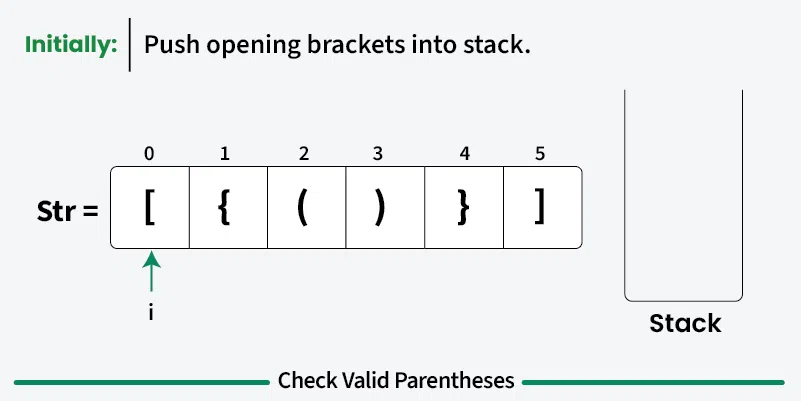
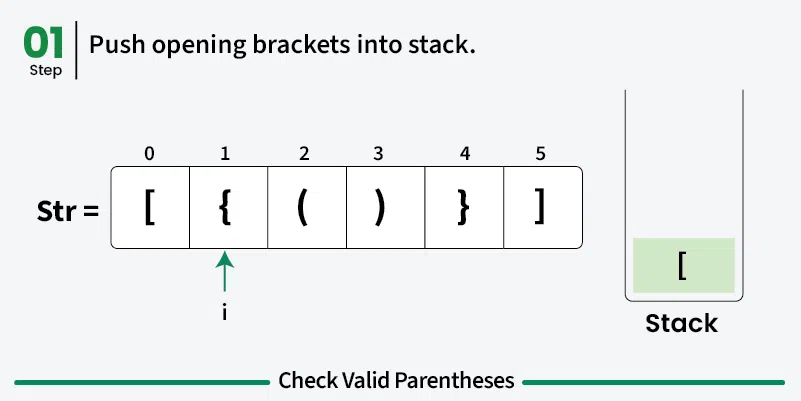
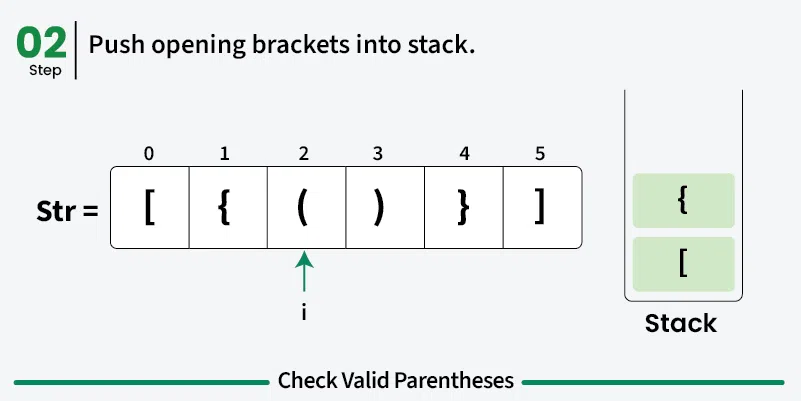
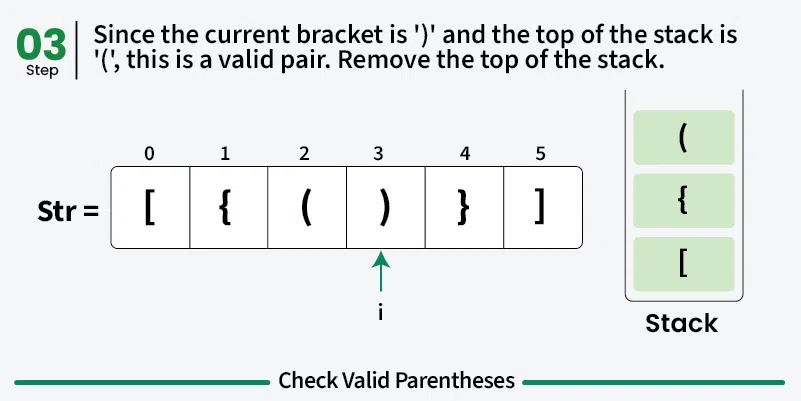
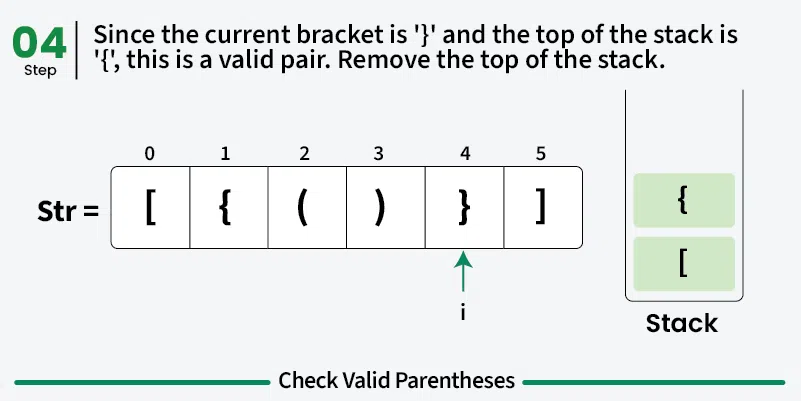
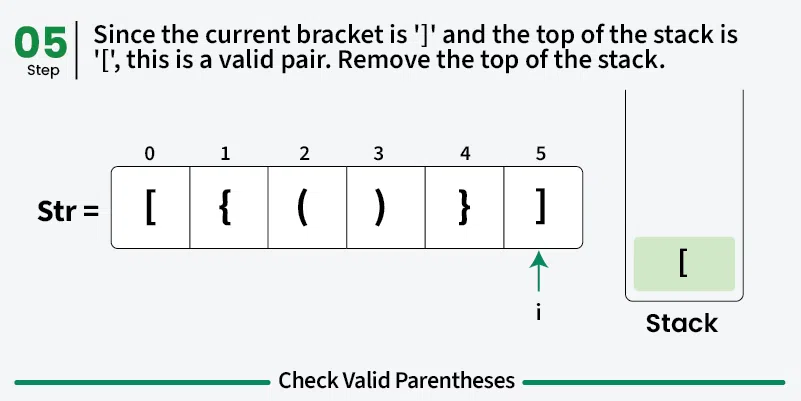
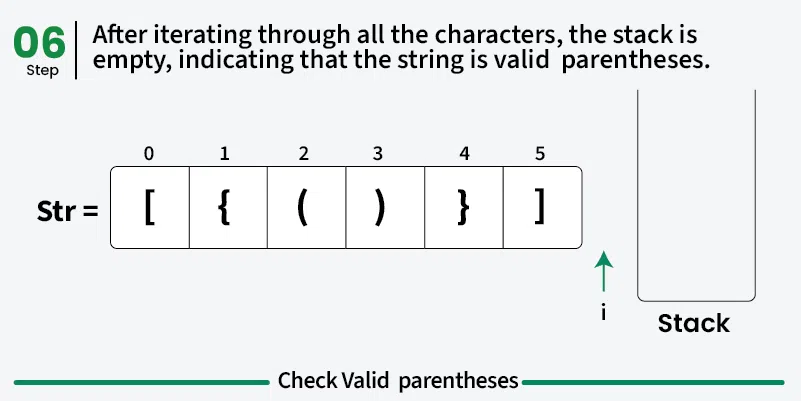


---
### Why Do We Check stack[-1]?

top = stack[-1]

stack[-1] gives us the top/most recently added element.

This is important because brackets must be closed in reverse order.

For:

[{()}]

The opening order is:

[
{
(

Therefore, the closing order must be:

)
}
]

This is exactly what a stack gives us:

Last opened → First closed

That is why a stack is the natural data structure for this problem.

---
### Why Do We Check if not stack?

```python
if not stack:
```

Consider:

"}"

There is a closing bracket, but we have not seen any opening bracket.

stack = []

There is therefore nothing that } can match with.

Without this check, trying to access:

stack[-1]

would cause an IndexError.

So this check handles the case where a closing bracket appears before its corresponding opening bracket.

---
### Why Do We Check not stack Again at the End?

Consider:

"[["

While processing:

[

we push it.

stack = ["["]

Then the second [ is also pushed:

stack = ["[", "["]

No mismatch occurred, so is_valid is still True.

But the string is obviously invalid because both opening brackets are still unmatched.

Therefore:

if is_valid and not stack:

checks that all opening brackets have eventually been closed.

---

In [19]:
# str = "[{()}]"
# str= "}"
str = "[{(])}"

# Using dict for comparison
mapping = {
    "}": "{",
    "]":"[",
    ")":"("}

stack=[]
is_valid= True

for char in str:
    if char in "[({":
        stack.append(char)

    elif char in "])}":

        if not stack:
            is_valid = False
            print("Invalid: Closing bracket has no matching opening bracket.")
            break

        top = stack[-1]

        if (mapping[char] != top):
            is_valid = False
            print("Invalid: Brackets are not properly nested.")
            break

        stack.pop()


if is_valid and not stack:
    print("Valid parentheses!")
else:
     print("Invalid parenthese!")

        

Invalid: Brackets are not properly nested.
Invalid parenthese!


---

## Invalid Example: Wrong Nesting

Consider:

"[{(])}"

Processing gives:

[ -> "["

{ -> "[{"

( -> "[{("

Now we encounter:

]

The top of the stack is:

(

But ] should close:

[

So:

mapping["]"] != top

becomes:

"[" != "("

Therefore the string is invalid.

The important point is that having the correct number of opening and closing brackets is not enough.

---

## Complexity

Let n be the length of the string.

Time Complexity: O(n)

We traverse the string once.
Each bracket is pushed onto or popped from the stack at most once.

Space Complexity: O(n)

In the worst case, the string contains only opening brackets:

[[[[[[[[[

All of them will be stored in the stack.

---

# Q5: First Non-Repeating Character

Given a string, find the first character that occurs exactly once.

Example:

Input: swiss

Output: w

---

In [33]:
str= "swiss"
dict ={}


for char in str:
        dict[char] = dict.get(char, 0) + 1

print(f"The counts of each character: {dict}")

# Walk the ORIGINAL STRING (the only thing that
# actually knows what came first), and check the already-known count.
for char in str:
    if dict[char] == 1:
        print(char)
        break       

# Works, but only because Python dicts preserve insertion order (3.7+) —
# correct by coincidence, not because this loop reads string order directly.
for freq,key in dict.items():
        if key == 1:
                print(freq,key)
                break


The counts of each character: {'s': 3, 'w': 1, 'i': 1}
w
w 1


### EXPLANATION:

    Input:  "swiss"
    Output: "w"

    Walk the string left to right. For each character ask: "does this
    character occur exactly once in the ENTIRE string?" Stop at the first
    one where the answer is yes.

    Important: you can't answer that question by looking only at
    characters seen SO FAR, or only forward from the current position.
    'w' in "wsw" is not the answer even though nothing repeats right next
    to it — there's another 'w' further along. You need the character's
    TOTAL count across the whole string before you can judge it, even the
    character you're currently standing on.

    That's really two separate jobs pretending to be one problem:
        Job 1: get GLOBAL information  -> how many times does each char occur, total?
        Job 2: apply it in LOCAL, left-to-right order -> which one is first?


### JOB 1 — COUNT EVERYTHING (global knowledge, order doesn't matter here)
--------------------------------------------------------------------------------
    for char in str:
        dict[char] = dict.get(char, 0) + 1

    dict.get(char, 0) means "give me this character's count so far, or 0
    if it's never been seen." Then +1 bumps it.

    Trace on "swiss":
        s -> not seen (0) -> becomes 1        dict = {s:1}
        w -> not seen (0) -> becomes 1        dict = {s:1, w:1}
        i -> not seen (0) -> becomes 1        dict = {s:1, w:1, i:1}
        s -> seen once (1) -> becomes 2       dict = {s:2, w:1, i:1}
        s -> seen twice (2) -> becomes 3      dict = {s:3, w:1, i:1}

    Final: {s:3, w:1, i:1}. Job 1 is done — you now know the TOTAL count
    of every character. But this dict, by itself, does NOT tell you which
    character came first in the string. A dict of counts is just a bag of
    totals, it was never asked to remember position.


### JOB 2 — FIND THE FIRST ONE WITH COUNT 1 
--------------------------------------------------------------------------------
The only thing in this whole problem that actually knows what came first
IS THE ORIGINAL STRING. Not the dict, not a set built from it — the string.
So job 2 means going back to `str` and walking it AGAIN, left to right,
and this time checking the count you already know for each character:

    for char in str:
        if dict[char] == 1:
            print(char)
            break

Two passes, two different jobs:
    pass 1 -> gather knowledge you don't have a use for yet (the counts)
    pass 2 -> walk the sequence that actually has order, and use that
              knowledge the moment you have something to check

This "gather everything, then re-walk in the order that matters" shape
shows up in a lot of problems, not just this one — recognize it.

---

### WHY THE dict.items() VERSION ALSO HAPPENED TO WORK (but for a fragile reason)
    for freq, key in dict.items():
        if key == 1:
            print(freq, key)
            break

This gives the right answer, but not because it was DESIGNED to respect
string order. It works because Python dicts (3.7+) happen to preserve
INSERTION order as a language guarantee. Since 's', 'w', 'i' were inserted
into the dict in that exact order while counting, .items() later replays
that same order back — purely because of how dicts behave internally, not
because this loop is reading the string's order directly.

That's "correct by coincidence." The moment the dict got built from
something that ISN'T ordered (a set, for example), that accidental order
disappears immediately. Which is exactly why a set-based version of this
same idea breaks.

---

### WHY A set() VERSION CANNOT BE FIXED, ONLY AVOIDED
A set's entire job is: "give me each distinct thing once, and let me check
membership fast." That's it — nothing about WHEN something was seen was
ever part of that job. set("swiss") throws every character into a bucket
organized by hash value, which has NOTHING to do with left-to-right
position in the string. Iterating it could give you 's','w','i' or
'i','s','w' or any other arrangement — arbitrary from your side, and with
zero relationship to the original string.

The key realization: the order wasn't hidden somewhere inside the set,
it was DESTROYED the moment set(str) ran. It never entered the set in the
first place. So "how do I reverse the set back to original order" has no
answer — you can't recover information a structure never stored. There is
no fix for the set approach. The fix is to not ask a set to answer an
ordering question at all, and go back to the string instead, same as Job 2.

---


# Q6: String Compression

Given:

aaabbccccd

produce:

a3b2c4d1

---

In [49]:
# del str
# crypt = "aaabbccccd" # a3b2c4d1
crypt = "aabbaa" # a2b2a2

# ---------------
encrypt = {}
encrypt_str= ""

for char in crypt:
    # Count total occurrences of each character
    encrypt[char] = encrypt.get(char, 0) + 1

for key,value in encrypt.items():
    # Using an f-string automatically converts 'value' to a string
    encrypt_str += f"{key}{value}"

print(f"[Dictionary way] String compression of '{crypt}' is '{encrypt_str}'")


"""
--------------------------------------------------------------------------------
Why this approach is incomplete:
--------------------------------------------------------------------------------
It counts characters across the entire string, ignoring their positions.

Example:
    Input:  "aabbaa"
    Dictionary result: "a4b2"     ← Wrong
    Correct result:    "a2b2a2"   ← Characters are in separate groups

Conclusion:
    Dictionary method only works when the same characters are already
    grouped together. It fails in the general case.


Correct thinking:
    We should compress characters that appear one after another (consecutively).

Logic:
    1. Start with count = 1
    2. Walk through the string from the second character
    3. If current character is same as previous → increase count
    4. If current character is different:
          - Store previous character + its count
          - Reset count to 1 for the new character
    5. After the loop, don't forget to store the last group
"""

# The Correct way of the List compression
result = []
count = 1

for i in range(1, len(crypt)):
    if crypt[i] == crypt[i-1] :
        # Same character as previous → just increase the counter
        count += 1
    else:
        #Character changed -> write the previous group
        result.append(crypt[i-1] + str(count))
        count = 1 # reset for new character

# Important: Handle the very last group after the loop ends
result.append(crypt[-1] + str(count))

# Join the list into final string
dstr = "".join(result)
print(f"[Correct way]   String compression of '{crypt}' is '{dstr}'")

[Dictionary way] String compression of 'aabbaa' is 'a4b2'
[Correct way]   String compression of 'aabbaa' is 'a2b2a2'


---

# Walkthrough

Input: "aabbaa"

Index :  0    1    2    3    4    5
Char  :  a    a    b    b    a    a


1. DICTIONARY APPROACH (Global Count)
This method only cares about total count of each character.
It completely ignores the order and the groups.

Step-by-step building of the dictionary:

    char = 'a'  →  {'a': 1}
    char = 'a'  →  {'a': 2}
    char = 'b'  →  {'a': 2, 'b': 1}
    char = 'b'  →  {'a': 2, 'b': 2}
    char = 'a'  →  {'a': 3, 'b': 2}
    char = 'a'  →  {'a': 4, 'b': 2}

Final dictionary: {'a': 4, 'b': 2}

Now building the string:
    'a' + '4'  →  "a4"
    'b' + '2'  →  "a4b2"

Final result: "a4b2"          ← WRONG


2. CORRECT APPROACH (Consecutive Groups)
This method only counts continuous repeating characters.

Step-by-step:

    Start: count = 1

    i=1  (a == a)  → count = 2
    i=2  (b != a)  → store "a2" , reset count = 1
                     result = ["a2"]

    i=3  (b == b)  → count = 2
    i=4  (a != b)  → store "b2" , reset count = 1
                     result = ["a2", "b2"]

    i=5  (a == a)  → count = 2

    Loop ends      → store last group "a2"
                     result = ["a2", "b2", "a2"]

Final result: "a2b2a2"        ← CORRECT

---

# Q7: Reverse Words

Given:

"Python is easy to learn"

produce:

"learn to easy is Python"

***Do not use a direct reverse operation.***

---

In [ ]:
strr= "Python is easy to learn"
print(f"The original string: {strr}")
lst =[]

str= " "
for char in strr[::-1]:
    if char != " ":
        str+=char
    else:
        lst.append(str[::-1])
        str= " "

# The last word does not encounter a space,
# so it is still stored in str.
lst.append(str[::-1])
    
revstr = "".join(lst)
print(revstr)

learn to easy is Python 


---

### TraceBack for Above:

First reversing the entire string:

"Python is easy to learn"
            
            ↓ [::-1]

"nrael ot ysae si nohtyP"

---

Then rebuilding each word character-by-character.
So conceptually:

Reverse entire string
        
        ↓

Read characters from right → left
        
        ↓

Build reversed word
        
        ↓

Find space
        
        ↓

Reverse that word again
        
        ↓

Store it

---

Input: Python is easy to learn

So first reverse everything:

n r a e l   o t   y s a e   s i   n o h t y P

Now your loop processes:

| `char` | `str`                        | `lst`                        |
| ------ | ---------------------------- | ---------------------------- |
| `n`    | `" n"`                       | `[]`                         |
| `r`    | `" nr"`                      | `[]`                         |
| `a`    | `" nra"`                     | `[]`                         |
| `e`    | `" nrae"`                    | `[]`                         |
| `l`    | `" nrael"`                   | `[]`                         |
| ` `    | `" nrael"` → append reversed | `["learn"]`                  |
| `o`    | `" o"`                       | `["learn"]`                  |
| `t`    | `" ot"`                      | `["learn"]`                  |
| ` `    | `" ot"` → append reversed    | `["learn", "to"]`            |
| `s`    | `" s"`                       | ...                          |
| `i`    | `" si"`                      | ...                          |
| ` `    | `" si"` → append reversed    | `["learn","to","easy","is"]` |
| `n`    | `" n"`                       | ...                          |
| `y`    | `" nohty"`                   | ...                          |
| `P`    | `" nohtyP"`                  | ...                          |


And the loop ends here.

---

There is no space after P, so this never happens:
```
lst.append(...)
```

That's why you needed:
```
lst.append(str[::-1])
```
after the loop.

---

Your final state becomes:

lst

↓

["learn", "to", "easy", "is", "Python"]

Then:
"".join(lst)

produces:
learn to easy is Python

---

In [24]:
strr = "Python is easy to learn"

words = strr.split()

revstr = " ".join(words[::-1])

print(revstr)

learn to easy is Python


---

### Trace of the `split()` Approach  

Now look at how much simpler the processing is.

---

#### Step 1
```python
strr = "Python is easy to learn"
```

---

#### Step 2
```python
words = strr.split()
```

Immediately:
```python
["Python", "is", "easy", "to", "learn"]
```

We don't need to manually detect spaces.

---

#### Step 3
```python
words[::-1]
```

Python reverses the list:
```python
["learn", "to", "easy", "is", "Python"]
```

---

#### Step 4
```python
" ".join(words[::-1])
```

Join them with a space:
```
"learn to easy is Python"
```

Done ✅

---

## Nesting python built-ins( .join() & .split() ):

In [28]:
sentence = "Python is easy to learn"
revsentence = " ".join(sentence.split()[::-1])
print(revsentence)

learn to easy is Python


---

# Q8: Remove Substrings

Given a string and a list of substrings, remove every occurrence of those substrings.

Example:

String: "I love Python and Python is powerful"
Remove: ["Python", "powerful"]

---

In [20]:
print("Method 1:")
str = "I love Python and Python is powerful"
remove = ["Python", "powerful"]

word= []
strr = list(str.split())

for char in strr:
    if char not in remove:
        word.append(char)

print(" ".join(word))

print("\nMethod 2: List Comprehension (Cleaner)")
text = "I love Python and Python is powerful"
remove = ["Python", "powerful"]

result = [word for word in text.split() if word not in remove]

print(result)
print(" ".join(result))

print("\nMethod 3: Using filter")
text = "I love Python and Python is powerful"
remove = ["Python", "powerful"]

result = list(filter(lambda word: word not in remove, text.split()))
print(" ".join(result))

Method 1:
I love and is

Method 2: List Comprehension (Cleaner)
['I', 'love', 'and', 'is']
I love and is

Method 3: Using filter
I love and is


---

# Q9: Final Challenge: Data Analyzer

Build a program that receives a list of student records:

```python
students = [
    {"name": "A", "marks": [80, 75, 90]},
    {"name": "B", "marks": [65, 70, 72]},
    {"name": "C", "marks": [95, 92, 88]}
]

```


The program should calculate:

- Each student's average.
- Highest scorer.
- Lowest scorer.
- Top 3 students.
- Number of students passing.
- Subject-wise highest score.
- Overall average.
- Students scoring above the overall average.

---

In [49]:
students = [
    {"name": "A", "marks": [80, 75, 90]},
    {"name": "B", "marks": [65, 70, 72]},
    {"name": "C", "marks": [95, 92, 88]}
]

avg_marks= []
for i in students:
    avg_marks.append({i["name"]: round( (sum( i["marks"]) / len(i["marks"]) ), 2) })

print(*avg_marks)

highest_Scorer = max(sum(i["marks"]) for i in students)
for i in students:
    if sum(i['marks']) == highest_Scorer:
        print(f"The highest scorer is {i['name']} with score: {highest_Scorer}")

lowest_Scorer = min(sum(i["marks"]) for i in students)
for i in students:
    if sum(i['marks']) == lowest_Scorer:
        print(f"The lowest scorer is {i['name']} with score: {lowest_Scorer}")

# Sort students by total marks in descending order
top_students = sorted(students, key=lambda s: sum(s["marks"]), reverse=True)
print("\nTop 3 Students:")
for i, student in enumerate(top_students[:3], start=1):
    total = sum(student["marks"])
    print(f"{i}. {student['name']} - Total: {total}")


passing_count = 0
passing_marks = 70          # threshold
for student in students:
    avg = sum(student["marks"]) / len(student["marks"])
    if avg >= passing_marks:
        passing_count += 1

print(f"\nNumber of students passing (avg >= {passing_marks}): {passing_count}")

# Assuming 3 subjects
num_subjects = len(students[0]["marks"])
print("\nSubject-wise Highest Score:")
for sub in range(num_subjects):
    highest = max(student["marks"][sub] for student in students)
    print(f"Subject {sub+1}: {highest}")


overall_sum = 0
for i in students:
    overall_sum += sum(i['marks'])

overall_avg = round((overall_sum / 3), 2)
print("The overall average: ",overall_avg)

students_scoring_above_overall_avg = []
for i in students:
    if sum(i['marks']) >= overall_avg:
        students_scoring_above_overall_avg.append(i['name'])

print(f"Students scoring above the overall average '{overall_avg}' are : {students_scoring_above_overall_avg}")

{'A': 81.67} {'B': 69.0} {'C': 91.67}
The highest scorer is C with score: 275
The lowest scorer is B with score: 207

Top 3 Students:
1. C - Total: 275
2. A - Total: 245
3. B - Total: 207

Number of students passing (avg >= 70): 2

Subject-wise Highest Score:
Subject 1: 95
Subject 2: 92
Subject 3: 90
The overall average:  242.33
Students scoring above the overall average '242.33' are : ['A', 'C']


In [53]:
students = [
    {"name": "A", "marks": [80, 75, 90]},
    {"name": "B", "marks": [65, 70, 72]},
    {"name": "C", "marks": [95, 92, 88]}
]

# 1. Each student's average
print("Student Averages:")
for student in students:
    avg = round(sum(student["marks"]) / len(student["marks"]), 2)
    print(f"{student['name']}: {avg}")

# 2. Highest Scorer
highest_scorer = max(students, key=lambda s: sum(s["marks"]))
# print("\n",highest_scorer)
print(f"\nHighest Scorer: {highest_scorer['name']} with total {sum(highest_scorer['marks'])}")

# 3. Lowest Scorer
lowest_scorer = min(students, key=lambda s: sum(s["marks"]))
# print("\n",lowest_scorer)
print(f"Lowest Scorer: {lowest_scorer['name']} with total {sum(lowest_scorer['marks'])}")

# 4. Top 3 Students
top_students = sorted(students, key=lambda s: sum(s["marks"]), reverse=True)
print("\nTop 3 Students:")
for i, student in enumerate(top_students[:3], start=1):
    print(f"{i}. {student['name']} - Total: {sum(student['marks'])}")

# 5. Number of students passing
passing_count = 0
passing_marks = 70
for student in students:
    avg = sum(student["marks"]) / len(student["marks"])
    if avg >= passing_marks:
        passing_count += 1
print(f"\nNumber of students passing (avg >= {passing_marks}): {passing_count}")

# 6. Subject-wise highest score
print("\nSubject-wise Highest Score:")
num_subjects = len(students[0]["marks"])
for sub in range(num_subjects):
    highest = max(student["marks"][sub] for student in students)
    print(f"Subject {sub+1}: {highest}")

# 7. Overall average
total_marks = sum(sum(s["marks"]) for s in students)
total_subjects = sum(len(s["marks"]) for s in students)
overall_avg = round(total_marks / total_subjects, 2)
print(f"\nOverall Average: {overall_avg}")

# 8. Students scoring above overall average
print("\nStudents scoring above overall average:")
for student in students:
    avg = sum(student["marks"]) / len(student["marks"])
    if avg > overall_avg:
        print(student["name"])

Student Averages:
A: 81.67
B: 69.0
C: 91.67

Highest Scorer: C with total 275
Lowest Scorer: B with total 207

Top 3 Students:
1. C - Total: 275
2. A - Total: 245
3. B - Total: 207

Number of students passing (avg >= 70): 2

Subject-wise Highest Score:
Subject 1: 95
Subject 2: 92
Subject 3: 90

Overall Average: 80.78

Students scoring above overall average:
A
C
